<a href="https://colab.research.google.com/github/immischein/ML-bandgap/blob/main/DNN_MAE_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [194]:
!pip install category_encoders
!pip install skorch
!pip install optuna
!pip install optuna-integration[skorch]
!pip install shap

# Imports

In [89]:
from google.colab import drive

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer
from sklearn.preprocessing import OneHotEncoder

import category_encoders as ce

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from tqdm import tqdm

import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
import numpy as np

from skorch.helper import predefined_split
from skorch.dataset import Dataset
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

import shap
import category_encoders as ce
import time



### Load Datasets

In [7]:
drive.mount('/content/drive')

# load original dataset (all materials)
df_full = pd.read_csv('/content/drive/MyDrive/Project Documents ML-CMT/bandgap_dataset_full.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Data cleaning step

In [8]:
def initial_data_cleaning(df, target_col='band_gap', id_col='material_id', corr_thresh=0.95):
    df = df.copy()

    # Drop identifier
    if id_col in df.columns:
        df = df.drop(columns=id_col)

    # Separate target
    X = df.drop(columns=target_col)
    y = df[target_col]

    # Split first (to avoid leakage)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Drop columns with >65% missing
    missing_frac = X_train.isnull().mean()
    drop_cols = missing_frac[missing_frac > 0.65].index.tolist()
    print(f"Dropping columns with >65% missing values: {drop_cols}")
    X_train = X_train.drop(columns=drop_cols)
    X_test = X_test.drop(columns=drop_cols)

    # Correlation-based feature dropping (on train set only)
    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = []
    for col in upper.columns:
        for row in upper.index:
            if upper.loc[row, col] > corr_thresh:
                if row in to_drop or col in to_drop:
                    continue
                target_corr = X_train.corrwith(y_train)
                drop = row if target_corr[row] < target_corr[col] else col
                to_drop.append(drop)

    print(f"Dropping correlated features: {to_drop}")
    X_train = X_train.drop(columns=to_drop)
    X_test = X_test.drop(columns=to_drop)

    return X_train, X_test, y_train, y_test

### Preprocessing Pipeline

In [206]:
class TargetEncoderWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, column):
        self.column = column  # ✅ declared here, not in fit
        self.encoder_ = None  # ✅ trailing underscore: fitted object

    def fit(self, X, y):
        self.encoder_ = ce.TargetEncoder(cols=[self.column])
        self.encoder_.fit(X, y)
        return self

    def transform(self, X):
        return self.encoder_.transform(X)

            # Add this method to provide output feature names
    def get_feature_names_out(self, input_features=None):
        # The output feature name is the same as the input column name
        # Target encoding typically replaces the column in place
        return [self.column]


In [207]:
def build_preprocessor(numeric_cols, nonnumeric_cols, te_col='spacegroup_number '):
    if te_col in numeric_cols:
        numeric_cols = [col for col in numeric_cols if col != te_col]

    num_pipeline = make_pipeline(
        SimpleImputer(strategy='mean'),
        StandardScaler()
    )

    # cat_pipeline = make_pipeline(TargetEncoderWrapper())
    cat_pipeline = make_pipeline(TargetEncoderWrapper(column='spacegroup_number '))

    nonnumeric_pipeline = make_pipeline(
        SimpleImputer(strategy="most_frequent"),
        OneHotEncoder(handle_unknown="ignore")
    )

    preprocessor = make_column_transformer(
        (num_pipeline, numeric_cols),
        (cat_pipeline, [te_col]),
        (nonnumeric_pipeline, nonnumeric_cols)
    )

    return preprocessor


### Evaluation Pipeline

In [208]:
def run_final_test_evaluation(X_train, X_test, y_train, y_test, model_dict):
    final_results = []
    trained_pipelines = []

    # Detect column types
    te_col = 'spacegroup_number '
    numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
    nonnumeric_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

    # Remove target-encoded column from numeric
    if te_col in numeric_cols:
        numeric_cols.remove(te_col)

    for name, model in model_dict.items():
        print(f"\nTraining final model: {name}")

        # Build preprocessor and pipeline
        preprocessor = build_preprocessor(numeric_cols, nonnumeric_cols, te_col=te_col)
        pipeline = make_pipeline(preprocessor, model)

        # Fit on full training set
        pipeline.fit(X_train, y_train)

        # Evaluate on test set
        y_pred = pipeline.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        rmse_ = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        final_results.append({
            'Model': name,
            'Test MAE': mae,
            'Test RMSE': rmse_,
            'Test R²': r2
        })

        trained_pipelines.append((name, pipeline))

    return pd.DataFrame(final_results), dict(trained_pipelines)


# Manual Testing

In [90]:
# Clean data
X_train_full, X_test_full, y_train_full, y_test_full = initial_data_cleaning(df_full, target_col='band_gap')

Dropping columns with >65% missing values: []
Dropping correlated features: ['mean_distance', 'std_distance', 'std_am_weighted', 'std_vdw_weighted', 'std_molar_volume_weighted', 'electron_affinity_range_weighted', 'en_range', 'max_en ', 'avg_en', 'std_en', 'ie_range', 'max_ie ', 'min_ie', 'avg_am', 'am_range', 'max_am ', 'vdw_range', 'avg_vdw', 'max_vdw ', 'min_vdw', 'std_molar_volume', 'max_molar_volume ', 'electron_affinity_range', 'std_electron_affinity', 'avg_electronegativity', 'electronegativity_range', 'std_electronegativity', 'max_electronegativity ', 'min_electronegativity', 'atomic_radius_range', 'max_atomic_radius ', 'boiling_point_range', 'avg_boiling_point', 'max_boiling_point ']


In [91]:
# Make a copy of X_train_full
X_train = X_train_full.copy()
y_train = y_train_full.copy()

# Make a copy of X_test_full
X_test = X_test_full.copy()
y_test = y_test_full.copy()

## Preprocsss

In [36]:
te_col = 'spacegroup_number '
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
nonnumeric_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

if te_col in numeric_cols:
    numeric_cols.remove(te_col)

preprocessor = build_preprocessor(numeric_cols, nonnumeric_cols, te_col)
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

## Using Specified Models

In [197]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "MLP": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, early_stopping=True, random_state=42),
    "Random Forest (Ocunda)" : RandomForestRegressor(
    random_state=42,
    n_estimators=800, # number of trees
    max_depth=39, # maximum depth of the individual trees is unlimited
    min_samples_leaf=1, # minimum number of samples required to be at a leaf node
    min_samples_split=2, # minimum number of samples required to split an internal node
    max_features='sqrt', # number of features to consider when looking for the best split
    n_jobs=-1
    )
}

## Model Evaluation

In [101]:
# train models
# Cross validation with 5 folds is a typical choice
print("\nCross-validated MAE (5-fold):")
for name, model in models.items():
    pipeline = make_pipeline(preprocessor, model)
    scores = cross_val_score(pipeline, X_train, y_train,
                             scoring="neg_mean_absolute_error", cv=5)
    print(f"{name}: MAE = {-np.mean(scores):.3f}")


Cross-validated MAE (5-fold):
Linear Regression: MAE = 1.043
Random Forest: MAE = 0.666
MLP: MAE = 0.797
Random Forest (Ocunda): MAE = 0.677



Test set performance:
Linear Regression: MAE = 1.042, R² = 0.286
Random Forest: MAE = 0.636, R² = 0.667
MLP: MAE = 0.773, R² = 0.556
Random Forest (Ocunda): MAE = 0.650, R² = 0.658


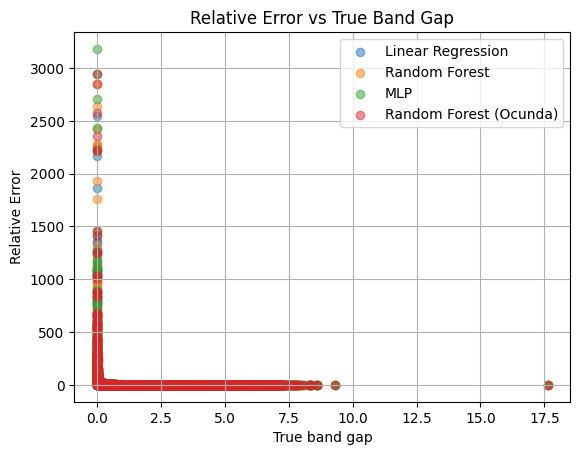

In [102]:
# Fit on full training set and evaluate on test set
results = {}
print("\nTest set performance:")
for name, model in models.items():
    pipeline = make_pipeline(preprocessor, model)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"mae": mae, "r2": r2}

    print(f"{name}: MAE = {mae:.3f}, R² = {r2:.3f}")

    # Plot MAE vs true value
    relative_error = np.abs(y_pred - y_test) / y_test
    plt.scatter(y_test, relative_error, label=name, alpha=0.5)

    #plt.scatter(y_test, np.abs(y_pred - y_test), label=name, alpha=0.5)

plt.xlabel("True band gap")
plt.ylabel("Relative Error")
plt.title("Relative Error vs True Band Gap")
plt.legend()
plt.grid(True)
plt.show()

## Testing Deep Neural Networks

In [104]:
# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_processed.toarray()
                              if hasattr(X_train_processed, "toarray")
                              else X_train_processed, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_processed.toarray()
                             if hasattr(X_test_processed, "toarray")
                             else X_test_processed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_full.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test_full.values, dtype=torch.float32).view(-1, 1)

In [105]:
# Define model
class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)

        )

    def forward(self, x):

        return self.net(x)

model_layers3 = DeepRegressor(X_train_tensor.shape[1])


### Run the model on GPU if available

In [106]:
# Put the model on the GPU if available
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)

model_layers3.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


### Define the training loop

In [107]:
import time
from tqdm import trange
import torch
import torch.nn as nn
import torch.optim as optim

def train_model(
    model,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=10,
    batch_size=64,
):
    """
    Trains a PyTorch regression model with early stopping and learning rate scheduling.

    Returns:
        model: The trained model with best weights
        train_losses: List of training loss per epoch
        test_losses: List of test loss per epoch
    """
    # Create DataLoader for training
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Setup
    start_time = time.time()
    criterion = nn.MSELoss()  # Mean squared error loss for regression
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)  # Adam optimizer
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=scheduler_factor, patience=scheduler_patience
    )  # Reduce LR on plateau

    train_losses = []
    test_losses = []
    best_loss = float('inf')
    trigger_times = 0

    for epoch in trange(n_epochs, desc="Training"):
        model.train()
        optimizer.zero_grad()
        y_pred_train = model(X_train_tensor)  # Forward pass on train set
        loss = criterion(y_pred_train, y_train_tensor)  # Compute train loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        model.eval()
        with torch.no_grad():
            y_pred_test = model(X_test_tensor)  # Forward pass on test set
            test_loss = criterion(y_pred_test, y_test_tensor)  # Compute test loss

        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        scheduler.step(test_loss.item())  # Step the LR scheduler

        # Early stopping logic
        if test_loss.item() < best_loss:
            best_loss = test_loss.item()
            best_model_state = model.state_dict()  # Save best model weights
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= early_stop_patience:
                print(f"\n⏹️ Early stopping at epoch {epoch}")
                break
        if epoch % verbose_every == 0:
            print(f"Epoch {epoch:4d} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f}")

    # Restore best model weights after training
    model.load_state_dict(best_model_state)

    # Report training time
    end_time = time.time()
    duration = end_time - start_time
    print(f"\n✅ Training completed in {duration:.2f} seconds ({duration / 60:.2f} minutes)")

    return model, train_losses, test_losses


### Train the Model

In [108]:
model_layers3, train_losses_layers3, test_losses_layers3 = train_model(
    model_layers3,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   1%|          | 41/5000 [00:00<00:12, 403.16it/s]

Epoch    0 | Train Loss: 6.2224 | Test Loss: 5.8950
Epoch   20 | Train Loss: 2.3319 | Test Loss: 2.3526
Epoch   40 | Train Loss: 2.0014 | Test Loss: 1.9970
Epoch   60 | Train Loss: 1.8452 | Test Loss: 1.8473


Training:   2%|▏         | 82/5000 [00:00<00:12, 402.75it/s]

Epoch   80 | Train Loss: 1.7551 | Test Loss: 1.7617


Training:   2%|▏         | 123/5000 [00:00<00:12, 401.77it/s]

...

Epoch 2840 | Train Loss: 0.7904 | Test Loss: 1.0353
Epoch 2860 | Train Loss: 0.7902 | Test Loss: 1.0353


Training:  58%|█████▊    | 2907/5000 [00:07<00:05, 404.44it/s]

Epoch 2880 | Train Loss: 0.7901 | Test Loss: 1.0353
Epoch 2900 | Train Loss: 0.7899 | Test Loss: 1.0353
Epoch 2920 | Train Loss: 0.7899 | Test Loss: 1.0353


Training:  59%|█████▊    | 2933/5000 [00:07<00:05, 401.98it/s]


⏹️ Early stopping at epoch 2933

✅ Training completed in 7.30 seconds (0.12 minutes)


### Evaluate the model

In [109]:
# Model evaluation
def evaluate_model(model, X_train_tensor, y_train, X_test_tensor, y_test, y_train_tensor=None):
    """
    Evaluates a trained PyTorch regression model on both training and test sets.

    Returns:
        Dictionary of metrics (MAE, RMSE, R²) for train and test sets
    """
    model.eval()

    with torch.no_grad():
        y_pred_test = model(X_test_tensor).detach().cpu().numpy()
        y_pred_train = model(X_train_tensor).detach().cpu().numpy()


    # Evaluate on test set
    mae_test = mean_absolute_error(y_test, y_pred_test)
    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_pred_test)

    # Evaluate on train set
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mse_train = mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_pred_train)

    return {
        "test": {"MAE": mae_test, "RMSE": rmse_test, "R2": r2_test, "y_pred_test": y_pred_test},
        "train": {"MAE": mae_train, "RMSE": rmse_train, "R2": r2_train, "y_pred_train": y_pred_train}
    }

### Analyze the model

In [110]:
# Plot learning curves
import matplotlib.pyplot as plt

def analyze_model(metrics, y_test,
                  train_losses, test_losses, model_name="PyTorch Model"):
    """
    Plots learning curves, prints metrics, and plots predicted vs. true values.
    """

    # 2. Plot learning curves
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"{model_name} Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 3. Print metrics
    print(f"[{model_name} - Test Set]")
    print(f"MAE:  {metrics['test']['MAE']:.4f}")
    print(f"RMSE: {metrics['test']['RMSE']:.4f}")
    print(f"R²:   {metrics['test']['R2']:.4f}")
    print(f"\n[{model_name} - Training Set]")
    print(f"MAE:  {metrics['train']['MAE']:.4f}")
    print(f"RMSE: {metrics['train']['RMSE']:.4f}")
    print(f"R²:   {metrics['train']['R2']:.4f}")

    # 4. Plot predicted vs true values (test set)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, metrics['test']['y_pred_test'], alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    plt.xlabel("True Band Gap")
    plt.ylabel("Predicted Band Gap")
    plt.title(f"{model_name} - Predicted vs True (Test Set)")
    plt.grid(True)
    plt.show()


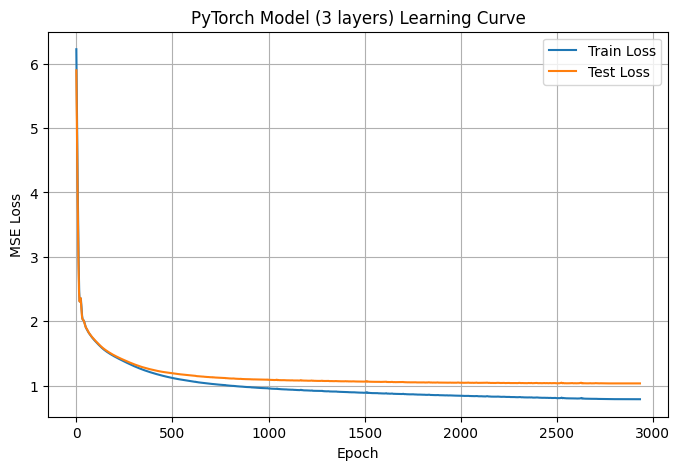

[PyTorch Model (3 layers) - Test Set]
MAE:  0.7547
RMSE: 1.0175
R²:   0.5711

[PyTorch Model (3 layers) - Training Set]
MAE:  0.6650
RMSE: 0.8887
R²:   0.6735


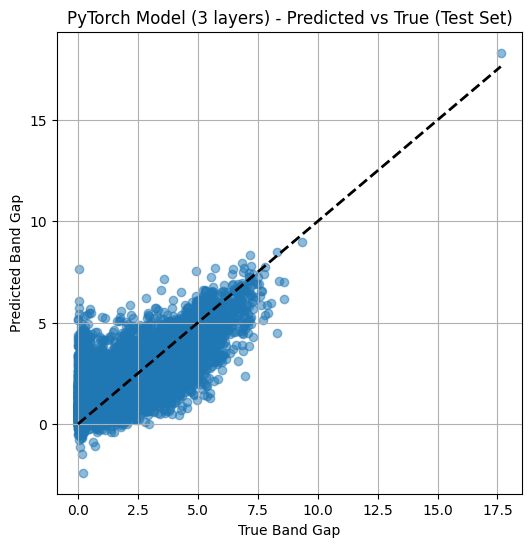

In [111]:
# Make a metrics dictionary
model_layers3_metrics = evaluate_model(
    model_layers3,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers3_metrics,
    y_test,
    train_losses_layers3,
    test_losses_layers3,
    model_name="PyTorch Model (3 layers)"
)

## 6 Layers Network

In [112]:
class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(  # Define the network layers
            nn.Linear(input_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)  # Output layer (no activation for regression)
        )

    def forward(self, x):
        return self.net(x)

# Initialize the model with the input dimension (number of features)
model_layers6 = DeepRegressor(X_train_tensor.shape[1])

In [113]:

if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)

model_layers6.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [114]:
model_layers6, train_losses_layers6, test_losses_layers6 = train_model(
    model_layers6,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Epoch    0 | Train Loss: 5.9264 | Test Loss: 5.8694


Training:   0%|          | 13/5000 [00:00<00:40, 121.93it/s]

Epoch   20 | Train Loss: 2.6121 | Test Loss: 2.4171


Training:   1%|          | 39/5000 [00:00<00:41, 120.88it/s]

...

Epoch 1580 | Train Loss: 0.7700 | Test Loss: 0.9145


Training:  32%|███▏      | 1598/5000 [00:13<00:28, 120.87it/s]

Epoch 1600 | Train Loss: 0.7664 | Test Loss: 0.9147


Training:  32%|███▏      | 1612/5000 [00:13<00:28, 120.47it/s]


⏹️ Early stopping at epoch 1612

✅ Training completed in 13.38 seconds (0.22 minutes)


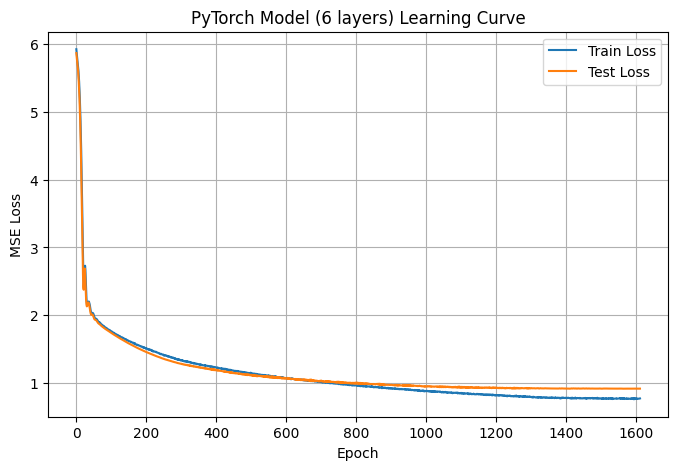

[PyTorch Model (6 layers) - Test Set]
MAE:  0.7007
RMSE: 0.9566
R²:   0.6209

[PyTorch Model (6 layers) - Training Set]
MAE:  0.5849
RMSE: 0.7746
R²:   0.7519


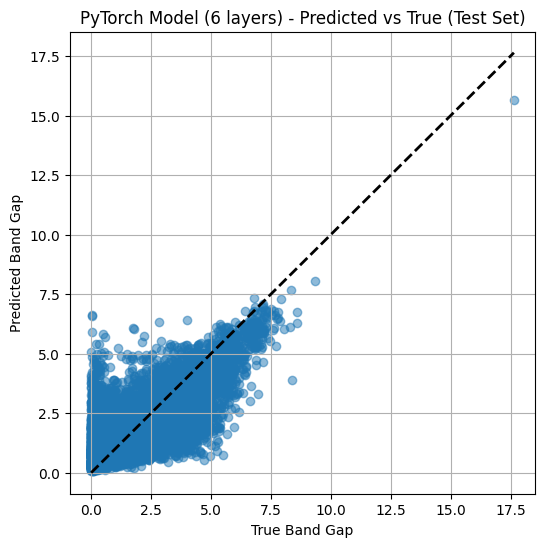

In [115]:
# Make a metrics dictionary
model_layers6_metrics = evaluate_model(
    model_layers6,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers6_metrics,
    y_test,
    train_losses_layers6,
    test_losses_layers6,
    model_name="PyTorch Model (6 layers)"
)

## 8 Layers Network

In [116]:
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),  # Layer 1
            nn.ReLU(),

            nn.Linear(512, 384),        # Layer 2
            nn.ReLU(),

            nn.Linear(384, 256),        # Layer 3
            nn.ReLU(),

            nn.Linear(256, 192),        # Layer 4
            nn.ReLU(),

            nn.Linear(192, 128),        # Layer 5
            nn.ReLU(),

            nn.Linear(128, 96),         # Layer 6
            nn.ReLU(),

            nn.Linear(96, 64),          # Layer 7
            nn.ReLU(),

            nn.Linear(64, 32),          # Layer 8
            nn.ReLU(),

            nn.Linear(32, 1)            # Output Layer
        )

    def forward(self, x):
        return self.net(x)

# Initialize the model with the input dimension (number of features)
model_layers8 = DeepRegressor(X_train_tensor.shape[1])

In [117]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)

model_layers8.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [118]:
model_layers8, train_losses_layers8, test_losses_layers8 = train_model(
    model_layers8,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 4/5000 [00:00<02:46, 30.03it/s]

Epoch    0 | Train Loss: 5.8313 | Test Loss: 5.7733


Training:   1%|          | 26/5000 [00:00<02:53, 28.69it/s]

Epoch   20 | Train Loss: 2.3093 | Test Loss: 2.1373


Training:   1%|          | 44/5000 [00:01<02:53, 28.55it/s]

...

Epoch  640 | Train Loss: 0.9549 | Test Loss: 1.1062


Training:  13%|█▎        | 665/5000 [00:23<02:32, 28.35it/s]

Epoch  660 | Train Loss: 0.9564 | Test Loss: 1.1074


Training:  13%|█▎        | 674/5000 [00:23<02:32, 28.28it/s]


⏹️ Early stopping at epoch 674

✅ Training completed in 23.84 seconds (0.40 minutes)


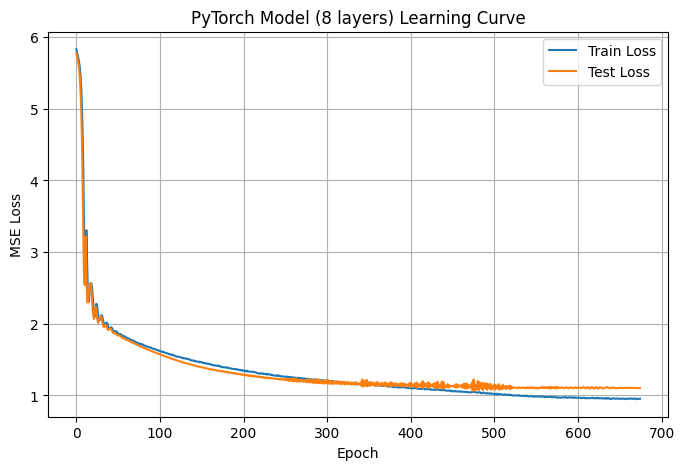

[PyTorch Model (8 layers) - Test Set]
MAE:  0.8054
RMSE: 1.0506
R²:   0.5427

[PyTorch Model (8 layers) - Training Set]
MAE:  0.7437
RMSE: 0.9585
R²:   0.6202


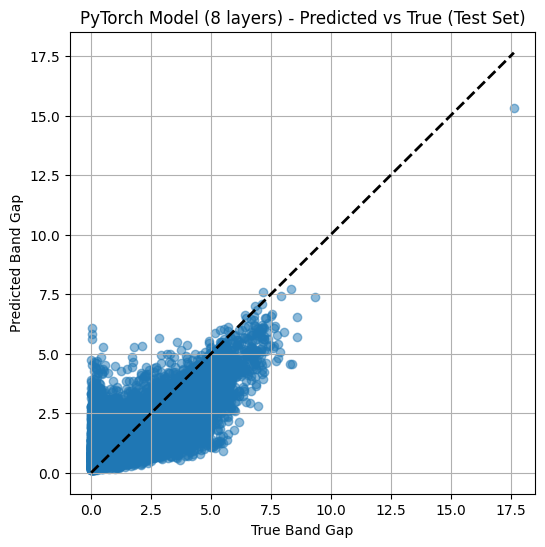

In [119]:
# Evaluate model
# Make a metrics dictionary
model_layers8_metrics = evaluate_model(
    model_layers8,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers8_metrics,
    y_test,
    train_losses_layers8,
    test_losses_layers8,
    model_name="PyTorch Model (8 layers)"
)

## 10 Layers Network

In [120]:
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),  # Layer 1
            nn.ReLU(),

            nn.Linear(512, 384),        # Layer 2
            nn.ReLU(),

            nn.Linear(384, 256),        # Layer 3
            nn.ReLU(),

            nn.Linear(256, 192),        # Layer 4
            nn.ReLU(),

            nn.Linear(192, 128),        # Layer 5
            nn.ReLU(),

            nn.Linear(128, 96),         # Layer 6
            nn.ReLU(),

            nn.Linear(96, 64),          # Layer 7
            nn.ReLU(),

            nn.Linear(64, 48),          # Layer 8
            nn.ReLU(),

            nn.Linear(48, 32),          # Layer 9
            nn.ReLU(),

            nn.Linear(32, 1)            # Layer 10 (Output)
        )

    def forward(self, x):
        return self.net(x)

# Initialize the model
model_layers10 = DeepRegressor(X_train_tensor.shape[1])


In [121]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)

model_layers10.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [122]:
model_layers10, train_losses_layers10, test_losses_layers10 = train_model(
    model_layers10,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 3/5000 [00:00<02:48, 29.66it/s]

Epoch    0 | Train Loss: 6.3558 | Test Loss: 6.3104


Training:   0%|          | 24/5000 [00:00<02:56, 28.20it/s]

Epoch   20 | Train Loss: 2.4539 | Test Loss: 2.2361


Training:   1%|          | 45/5000 [00:01<02:56, 28.11it/s]

...

Epoch  540 | Train Loss: 1.0494 | Test Loss: 1.1394


Training:  11%|█▏        | 564/5000 [00:20<02:38, 27.98it/s]

Epoch  560 | Train Loss: 1.0423 | Test Loss: 1.1334


Training:  12%|█▏        | 585/5000 [00:20<02:37, 27.96it/s]

Epoch  580 | Train Loss: 1.0500 | Test Loss: 1.1369

⏹️ Early stopping at epoch 585

✅ Training completed in 20.93 seconds (0.35 minutes)


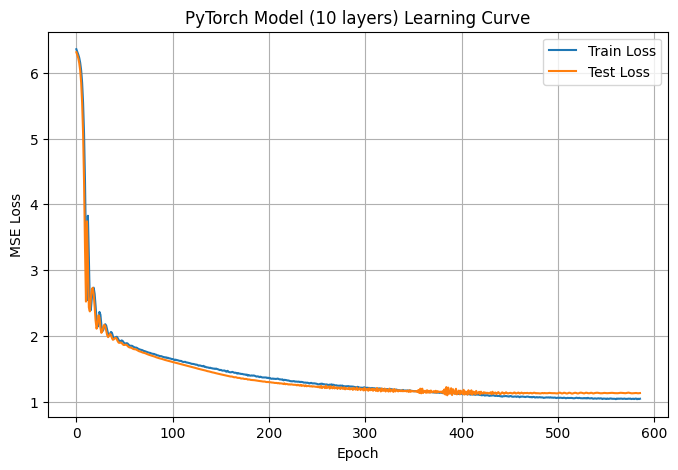

[PyTorch Model (10 layers) - Test Set]
MAE:  0.8213
RMSE: 1.0654
R²:   0.5298

[PyTorch Model (10 layers) - Training Set]
MAE:  0.7844
RMSE: 1.0079
R²:   0.5800


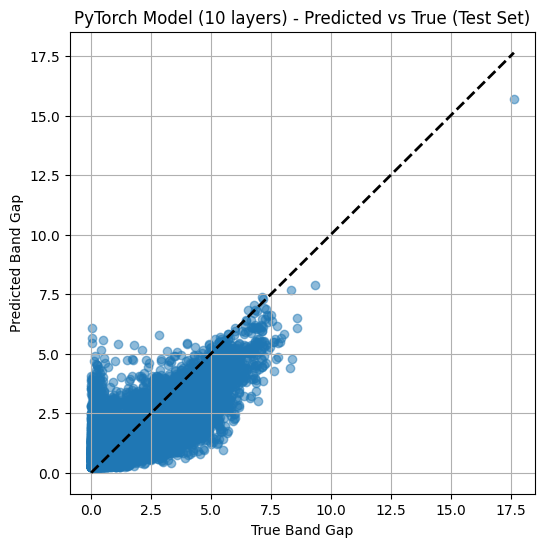

In [123]:
# Evaluate model
# Make a metrics dictionary
model_layers10_metrics = evaluate_model(
    model_layers10,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers10_metrics,
    y_test,
    train_losses_layers10,
    test_losses_layers10,
    model_name="PyTorch Model (10 layers)"
)


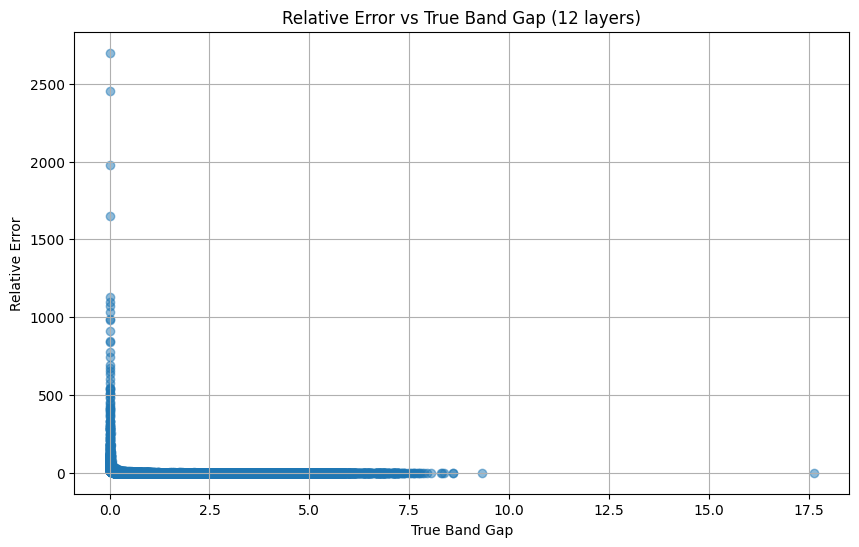

In [124]:
# relative error vs true band gap plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, np.abs(model_layers10_metrics['test']['y_pred_test'].flatten() - y_test) / y_test, alpha=0.5)
plt.xlabel("True Band Gap")
plt.ylabel("Relative Error")
plt.title("Relative Error vs True Band Gap (12 layers)")
plt.grid(True)
plt.show()

## 12 Layers Network

In [125]:
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 768),   # Layer 1
            nn.ReLU(),

            nn.Linear(768, 512),         # Layer 2
            nn.ReLU(),

            nn.Linear(512, 384),         # Layer 3
            nn.ReLU(),

            nn.Linear(384, 256),         # Layer 4
            nn.ReLU(),

            nn.Linear(256, 192),         # Layer 5
            nn.ReLU(),

            nn.Linear(192, 128),         # Layer 6
            nn.ReLU(),

            nn.Linear(128, 96),          # Layer 7
            nn.ReLU(),

            nn.Linear(96, 72),           # Layer 8
            nn.ReLU(),

            nn.Linear(72, 48),           # Layer 9
            nn.ReLU(),

            nn.Linear(48, 32),           # Layer 10
            nn.ReLU(),

            nn.Linear(32, 16),           # Layer 11
            nn.ReLU(),

            nn.Linear(16, 1)             # Layer 12 (Output)
        )

    def forward(self, x):
        return self.net(x)

# Initialize the 12-layer model
model_layers12 = DeepRegressor(X_train_tensor.shape[1])


In [126]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)

model_layers12.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [127]:
model_layers12, train_losses_layers12, test_losses_layers12 = train_model(
    model_layers12,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0, # L2 regularization
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 2/5000 [00:00<04:33, 18.26it/s]

Epoch    0 | Train Loss: 7.0848 | Test Loss: 7.0575


Training:   0%|          | 24/5000 [00:01<04:52, 17.02it/s]

Epoch   20 | Train Loss: 2.8875 | Test Loss: 2.6631


Training:   1%|          | 44/5000 [00:02<04:50, 17.06it/s]

...

Epoch  720 | Train Loss: 0.9172 | Test Loss: 1.0319


Training:  15%|█▍        | 744/5000 [00:44<04:15, 16.63it/s]

Epoch  740 | Train Loss: 0.9087 | Test Loss: 1.0332


Training:  15%|█▍        | 746/5000 [00:44<04:14, 16.72it/s]


⏹️ Early stopping at epoch 746

✅ Training completed in 44.63 seconds (0.74 minutes)


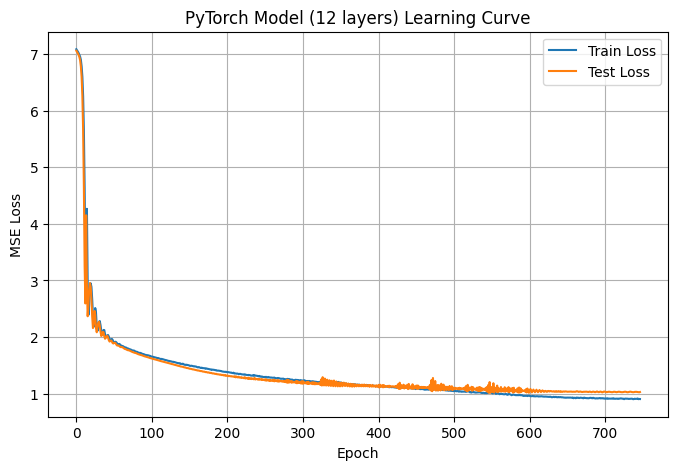

[PyTorch Model (12 layers) - Test Set]
MAE:  0.7680
RMSE: 1.0150
R²:   0.5732

[PyTorch Model (12 layers) - Training Set]
MAE:  0.6947
RMSE: 0.9058
R²:   0.6608


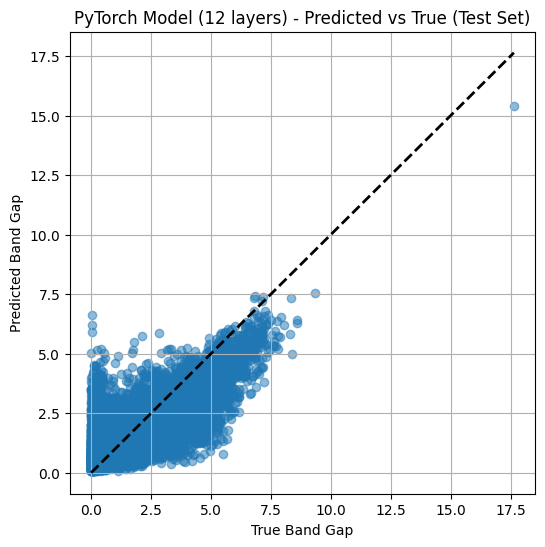

In [128]:
# Make a metrics dictionary
model_layers12_metrics = evaluate_model(
    model_layers12,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers12_metrics,
    y_test,
    train_losses_layers12,
    test_losses_layers12,
    model_name="PyTorch Model (12 layers)"
)

In [129]:
# shape of model_layers12_metrics['test']['y_pred_test']
print(model_layers12_metrics['test']['y_pred_test'].shape)
print(y_test.shape)

(16400, 1)
(16400,)


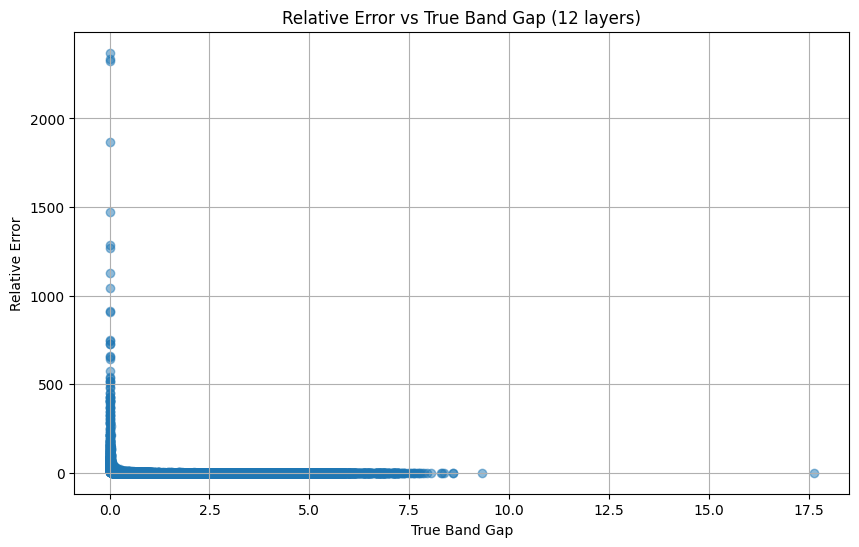

In [130]:
# relative error vs true band gap plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, np.abs(model_layers12_metrics['test']['y_pred_test'].flatten() - y_test) / y_test, alpha=0.5)
plt.xlabel("True Band Gap")
plt.ylabel("Relative Error")
plt.title("Relative Error vs True Band Gap (12 layers)")
plt.grid(True)
plt.show()

## 14 Layers Network

In [131]:
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 768),   # Layer 1
            nn.ReLU(),

            nn.Linear(768, 512),         # Layer 2
            nn.ReLU(),

            nn.Linear(512, 384),         # Layer 3
            nn.ReLU(),

            nn.Linear(384, 320),         # Layer 4
            nn.ReLU(),

            nn.Linear(320, 256),         # Layer 5
            nn.ReLU(),

            nn.Linear(256, 192),         # Layer 6
            nn.ReLU(),

            nn.Linear(192, 160),         # Layer 7
            nn.ReLU(),

            nn.Linear(160, 128),         # Layer 8
            nn.ReLU(),

            nn.Linear(128, 96),          # Layer 9
            nn.ReLU(),

            nn.Linear(96, 72),           # Layer 10
            nn.ReLU(),

            nn.Linear(72, 48),           # Layer 11
            nn.ReLU(),

            nn.Linear(48, 32),           # Layer 12
            nn.ReLU(),

            nn.Linear(32, 16),           # Layer 13
            nn.ReLU(),

            nn.Linear(16, 1)             # Layer 14 (Output)
        )

    def forward(self, x):
        return self.net(x)

# Initialize the 14-layer model
model_layers14 = DeepRegressor(X_train_tensor.shape[1])

In [132]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)



model_layers14.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [133]:
model_layers14, train_losses_layers14, test_losses_layers14 = train_model(
    model_layers14,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0, # L2 regularization
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 2/5000 [00:00<05:28, 15.21it/s]

Epoch    0 | Train Loss: 5.9498 | Test Loss: 5.9065


Training:   0%|          | 22/5000 [00:01<05:49, 14.25it/s]

Epoch   20 | Train Loss: 2.9694 | Test Loss: 2.7827


Training:   1%|          | 42/5000 [00:02<05:53, 14.01it/s]

...

Epoch  780 | Train Loss: 0.8000 | Test Loss: 0.9717


Training:  16%|█▌        | 802/5000 [00:57<04:56, 14.16it/s]

Epoch  800 | Train Loss: 0.7926 | Test Loss: 0.9702


Training:  16%|█▌        | 812/5000 [00:57<04:58, 14.03it/s]


⏹️ Early stopping at epoch 812

✅ Training completed in 57.86 seconds (0.96 minutes)


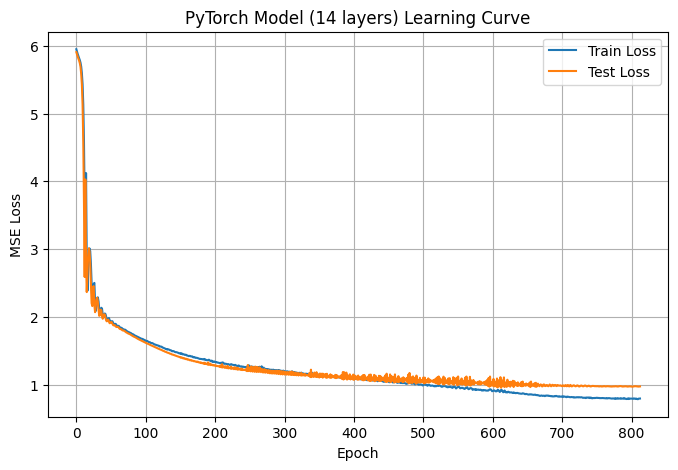

[PyTorch Model (14 layers) - Test Set]
MAE:  0.7371
RMSE: 0.9864
R²:   0.5969

[PyTorch Model (14 layers) - Training Set]
MAE:  0.6279
RMSE: 0.8240
R²:   0.7193


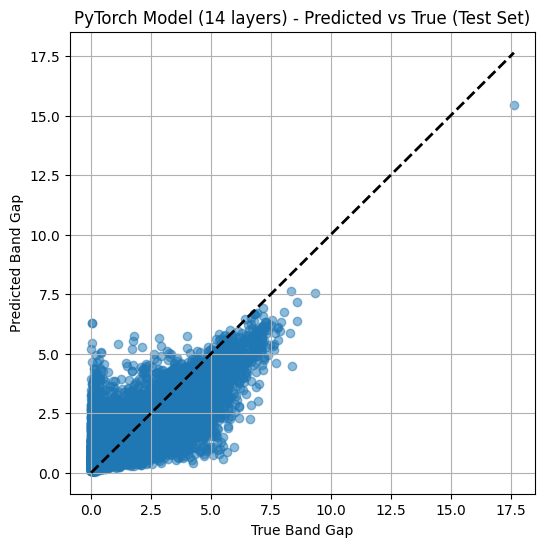

In [134]:
# Make a metrics dictionary
model_layers14_metrics = evaluate_model(
    model_layers14,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)

# Analyze the model
analyze_model(
    model_layers14_metrics,
    y_test,
    train_losses_layers14,
    test_losses_layers14,
    model_name="PyTorch Model (14 layers)"
)

## Adding Droppout

### 6 Layers

In [176]:
class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)  # Output layer (no activation for regression)
        )

    def forward(self, x):
        return self.net(x)
# Initialize the model with the input dimension (number of features)
model_layers6_dropout = DeepRegressor(X_train_tensor.shape[1])

In [177]:

if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)

model_layers6_dropout.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [178]:
model_layers6_dropout, train_losses_layers6_dropout, test_losses_layers6_dropout = train_model(
    model_layers6_dropout,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 24/5000 [00:00<00:43, 115.43it/s]

Epoch    0 | Train Loss: 6.8069 | Test Loss: 6.6677
Epoch   20 | Train Loss: 2.6016 | Test Loss: 2.3052


Training:   1%|          | 60/5000 [00:00<00:42, 115.12it/s]

Epoch   40 | Train Loss: 2.0855 | Test Loss: 1.9885
Epoch   60 | Train Loss: 1.9173 | Test Loss: 1.8469


Training:   2%|▏         | 96/5000 [00:00<00:42, 114.88it/s]

...

Epoch 1720 | Train Loss: 0.7752 | Test Loss: 0.9296
Epoch 1740 | Train Loss: 0.7730 | Test Loss: 0.9288


Training:  36%|███▌      | 1776/5000 [00:15<00:27, 115.46it/s]

Epoch 1760 | Train Loss: 0.7841 | Test Loss: 0.9298
Epoch 1780 | Train Loss: 0.7804 | Test Loss: 0.9295


Training:  36%|███▌      | 1803/5000 [00:15<00:27, 114.99it/s]

Epoch 1800 | Train Loss: 0.7817 | Test Loss: 0.9295

⏹️ Early stopping at epoch 1803

✅ Training completed in 15.68 seconds (0.26 minutes)


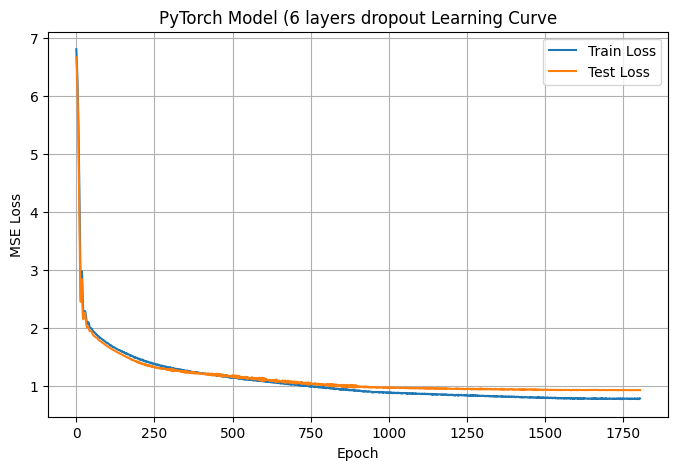

[PyTorch Model (6 layers dropout - Test Set]
MAE:  0.7137
RMSE: 0.9640
R²:   0.6150

[PyTorch Model (6 layers dropout - Training Set]
MAE:  0.6006
RMSE: 0.7838
R²:   0.7460


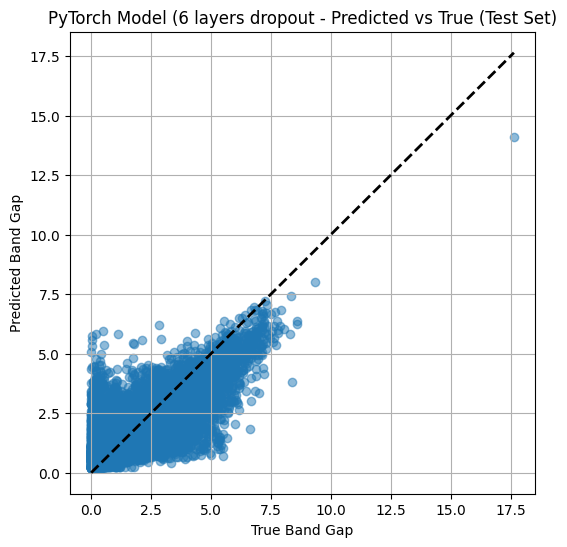

In [181]:
# Make a metrics dictionary
model_layers6_dropout_metrics = evaluate_model(
    model_layers6_dropout,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers6_dropout_metrics,
    y_test,
    train_losses_layers6_dropout,
    test_losses_layers6_dropout,
    model_name="PyTorch Model (6 layers dropout"
)

### 8 Layers

In [184]:
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 640),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(640, 512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 384),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(384, 256),
            nn.ReLU(),

            nn.Linear(256, 192),
            nn.ReLU(),

            nn.Linear(192, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)  # Output
        )

    def forward(self, x):
        return self.net(x)


In [185]:
# Initialize the 8-layer model
model_layers8_dropout = DeepRegressor(X_train_tensor.shape[1])

In [186]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)



model_layers8_dropout.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [187]:
model_layers8_dropout, train_losses_layers8_dropout, test_losses_layers8_dropout = train_model(
    model_layers8_dropout,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 3/5000 [00:00<04:12, 19.80it/s]

Epoch    0 | Train Loss: 7.1739 | Test Loss: 7.1103


Training:   0%|          | 23/5000 [00:01<04:23, 18.86it/s]

Epoch   20 | Train Loss: 2.4351 | Test Loss: 2.4658


Training:   1%|          | 43/5000 [00:02<04:22, 18.85it/s]

...

Epoch  780 | Train Loss: 0.7890 | Test Loss: 0.9727


Training:  16%|█▌        | 803/5000 [00:42<03:44, 18.73it/s]

Epoch  800 | Train Loss: 0.7888 | Test Loss: 0.9718


Training:  16%|█▋        | 821/5000 [00:43<03:42, 18.76it/s]

Epoch  820 | Train Loss: 0.7806 | Test Loss: 0.9728

⏹️ Early stopping at epoch 821

✅ Training completed in 43.78 seconds (0.73 minutes)


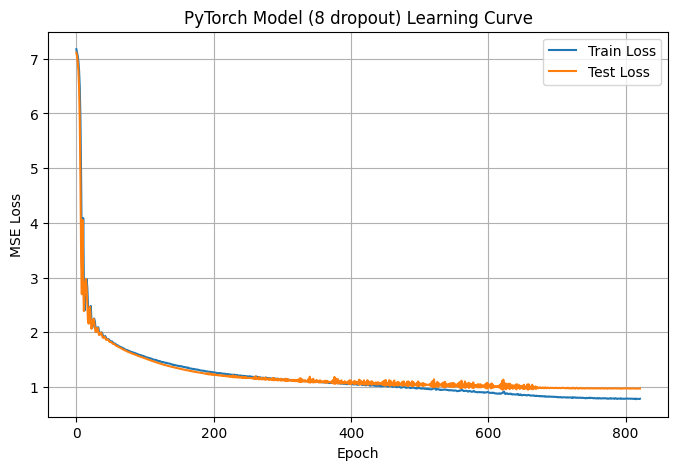

[PyTorch Model (8 dropout) - Test Set]
MAE:  0.7368
RMSE: 0.9862
R²:   0.5971

[PyTorch Model (8 dropout) - Training Set]
MAE:  0.6266
RMSE: 0.8224
R²:   0.7203


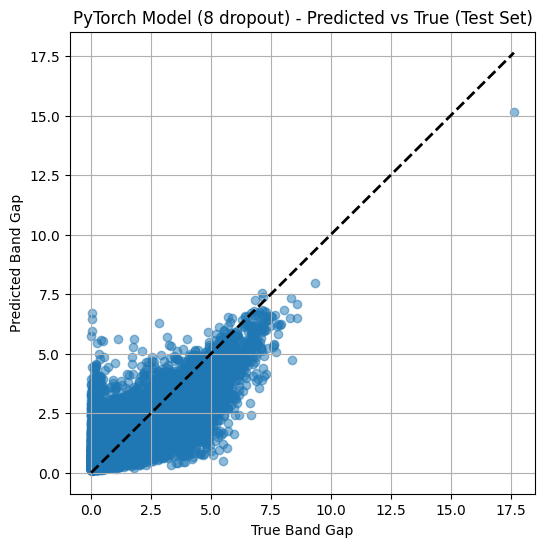

In [188]:
# Make a metrics dictionary
model_layers8_dropout_metrics = evaluate_model(
    model_layers8_dropout,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers8_dropout_metrics,
    y_test,
    train_losses_layers8_dropout,
    test_losses_layers8_dropout,
    model_name="PyTorch Model (8 dropout)"
)

### 10 Layers

In [169]:
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 384),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(256, 192),
            nn.ReLU(),

            nn.Linear(192, 128),
            nn.ReLU(),

            nn.Linear(128, 96),
            nn.ReLU(),

            nn.Linear(96, 64),
            nn.ReLU(),

            nn.Linear(64, 48),
            nn.ReLU(),

            nn.Linear(48, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


In [170]:
# Initialize the 10-layer model
model_layers10_dropout = DeepRegressor(X_train_tensor.shape[1])

In [171]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)



model_layers10_dropout.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [172]:
model_layers10_dropout, train_losses_layers10_dropout, test_losses_layers10_dropout = train_model(
    model_layers10_dropout,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 6/5000 [00:00<02:52, 28.95it/s]

Epoch    0 | Train Loss: 6.4657 | Test Loss: 6.4230


Training:   0%|          | 24/5000 [00:00<02:53, 28.62it/s]

Epoch   20 | Train Loss: 2.7051 | Test Loss: 2.5299


Training:   1%|          | 45/5000 [00:01<02:54, 28.47it/s]

...

Epoch  700 | Train Loss: 0.8412 | Test Loss: 0.9922


Training:  15%|█▍        | 726/5000 [00:25<02:31, 28.26it/s]

Epoch  720 | Train Loss: 0.8401 | Test Loss: 0.9892


Training:  15%|█▍        | 729/5000 [00:25<02:31, 28.14it/s]


⏹️ Early stopping at epoch 729

✅ Training completed in 25.91 seconds (0.43 minutes)


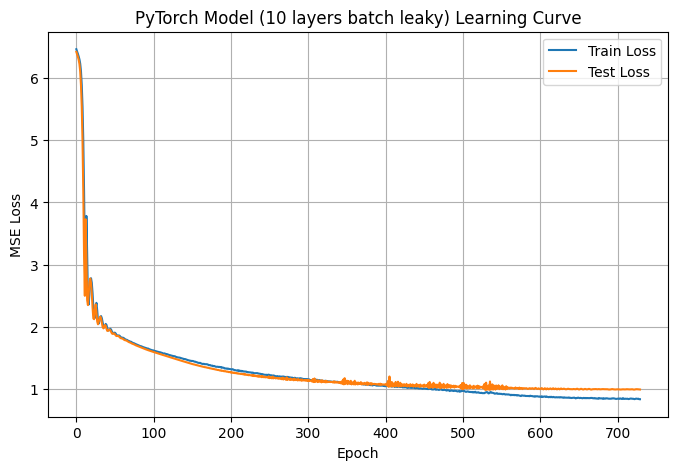

[PyTorch Model (10 layers batch leaky) - Test Set]
MAE:  0.7436
RMSE: 0.9945
R²:   0.5903

[PyTorch Model (10 layers batch leaky) - Training Set]
MAE:  0.6495
RMSE: 0.8519
R²:   0.7000


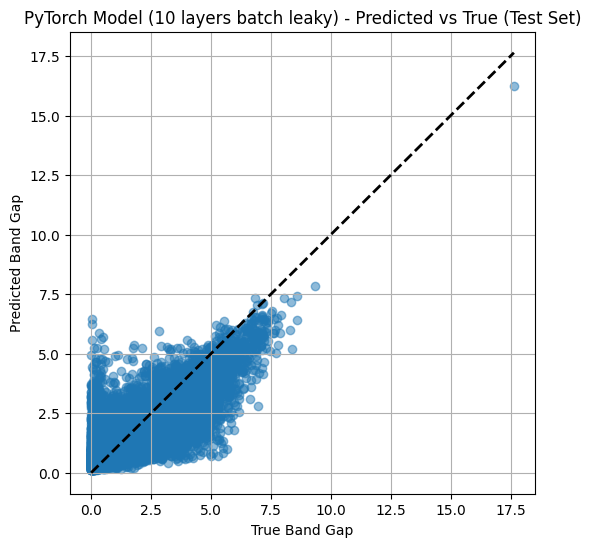

In [173]:
# Make a metrics dictionary
model_layers10_dropout_metrics = evaluate_model(
    model_layers10_dropout,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers10_dropout_metrics,
    y_test,
    train_losses_layers10_dropout,
    test_losses_layers10_dropout,
    model_name="PyTorch Model (10 layers batch leaky)"
)

## Adding Leaky Relu, batchnorm, and dropout

### 6 Layers

In [151]:
class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(),

            nn.Linear(16, 1)  # Output layer (no activation for regression)
        )

    def forward(self, x):
        return self.net(x)
# Initialize the model with the input dimension (number of features)
model_layers6_batch_leaky = DeepRegressor(X_train_tensor.shape[1])

In [152]:

if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)

model_layers6_batch_leaky.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [153]:
model_layers6_batch_leaky, train_losses_layers6_batch_leaky, test_losses_layers6_batch_leaky = train_model(
    model_layers6_batch_leaky,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 9/5000 [00:00<01:02, 80.19it/s]

Epoch    0 | Train Loss: 5.8262 | Test Loss: 6.7958


Training:   1%|          | 34/5000 [00:00<01:02, 79.85it/s]

Epoch   20 | Train Loss: 3.9294 | Test Loss: 4.6070


Training:   1%|          | 50/5000 [00:00<01:02, 79.70it/s]

...

Epoch 1320 | Train Loss: 0.6866 | Test Loss: 0.8699


Training:  27%|██▋       | 1355/5000 [00:16<00:45, 79.99it/s]

Epoch 1340 | Train Loss: 0.6920 | Test Loss: 0.8689


Training:  27%|██▋       | 1359/5000 [00:17<00:45, 79.69it/s]


⏹️ Early stopping at epoch 1359

✅ Training completed in 17.06 seconds (0.28 minutes)


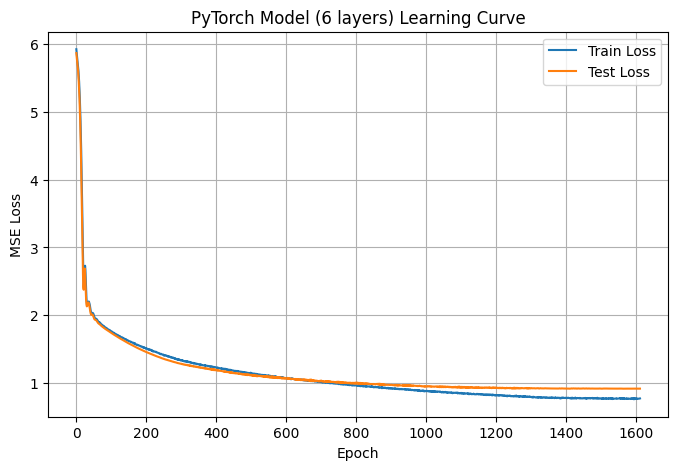

[PyTorch Model (6 layers) - Test Set]
MAE:  0.6666
RMSE: 0.9327
R²:   0.6396

[PyTorch Model (6 layers) - Training Set]
MAE:  0.5153
RMSE: 0.6831
R²:   0.8071


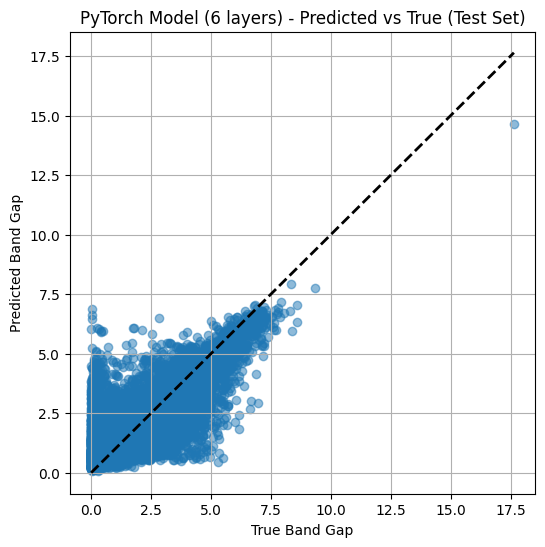

In [154]:
# Make a metrics dictionary
model_layers6_batch_leaky_metrics = evaluate_model(
    model_layers6_batch_leaky,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers6_batch_leaky_metrics,
    y_test,
    train_losses_layers6_batch_leaky,
    test_losses_layers6_batch_leaky,
    model_name="PyTorch Model (6 layers)"
)

### 8 Layers

In [135]:
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 640),
            nn.BatchNorm1d(640),
            nn.LeakyReLU(),
            nn.Dropout(0.2),

            nn.Linear(640, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 384),
            nn.BatchNorm1d(384),
            nn.LeakyReLU(),
            nn.Dropout(0.15),

            nn.Linear(384, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),

            nn.Linear(256, 192),
            nn.BatchNorm1d(192),
            nn.LeakyReLU(),

            nn.Linear(192, 128),
            nn.LeakyReLU(),

            nn.Linear(128, 64),
            nn.LeakyReLU(),

            nn.Linear(64, 32),
            nn.LeakyReLU(),

            nn.Linear(32, 1)  # Output
        )

    def forward(self, x):
        return self.net(x)


In [136]:
# Initialize the 8-layer model
model_layers8_batch_leaky = DeepRegressor(X_train_tensor.shape[1])

In [137]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)



model_layers8_batch_leaky.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [138]:
model_layers8_batch_leaky, train_losses_layers8_batch_leaky, test_losses_layers8_batch_leaky = train_model(
    model_layers8_batch_leaky,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 2/5000 [00:00<05:49, 14.29it/s]

Epoch    0 | Train Loss: 5.7480 | Test Loss: 5.8002


Training:   0%|          | 22/5000 [00:01<06:09, 13.48it/s]

Epoch   20 | Train Loss: 1.4755 | Test Loss: 1.5637


Training:   1%|          | 42/5000 [00:03<06:10, 13.38it/s]

...

Epoch  520 | Train Loss: 0.4753 | Test Loss: 0.8657


Training:  11%|█         | 542/5000 [00:39<05:31, 13.45it/s]

Epoch  540 | Train Loss: 0.4684 | Test Loss: 0.8642


Training:  11%|█         | 543/5000 [00:40<05:29, 13.53it/s]


⏹️ Early stopping at epoch 543

✅ Training completed in 40.15 seconds (0.67 minutes)


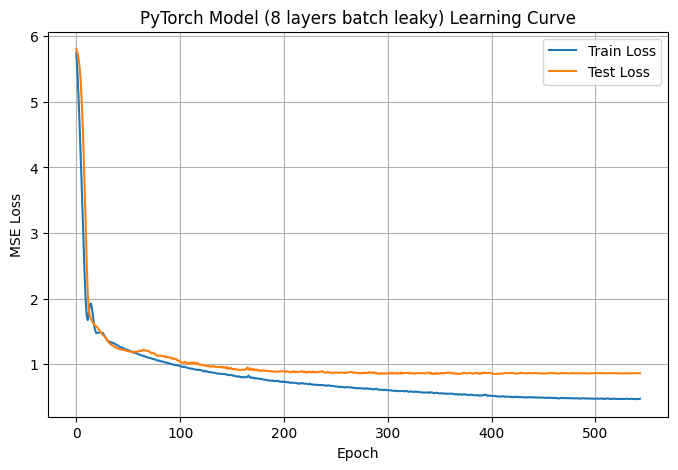

[PyTorch Model (8 layers batch leaky) - Test Set]
MAE:  0.6318
RMSE: 0.9301
R²:   0.6416

[PyTorch Model (8 layers batch leaky) - Training Set]
MAE:  0.3846
RMSE: 0.5266
R²:   0.8854


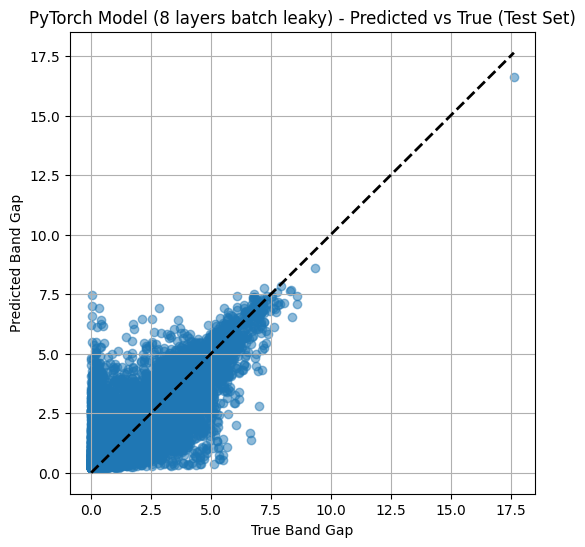

In [139]:
# Make a metrics dictionary
model_layers8_batch_leaky_metrics = evaluate_model(
    model_layers8_batch_leaky,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers8_batch_leaky_metrics,
    y_test,
    train_losses_layers8_batch_leaky,
    test_losses_layers8_batch_leaky,
    model_name="PyTorch Model (8 layers batch leaky)"
)

### 10 Layers

In [140]:
import torch.nn as nn

class DeepRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 384),
            nn.BatchNorm1d(384),
            nn.LeakyReLU(),
            nn.Dropout(0.2),

            nn.Linear(384, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Dropout(0.15),

            nn.Linear(256, 192),
            nn.BatchNorm1d(192),
            nn.LeakyReLU(),

            nn.Linear(192, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),

            nn.Linear(128, 96),
            nn.LeakyReLU(),

            nn.Linear(96, 64),
            nn.LeakyReLU(),

            nn.Linear(64, 48),
            nn.LeakyReLU(),

            nn.Linear(48, 32),
            nn.LeakyReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


In [141]:
# Initialize the 10-layer model
model_layers10_batch_leaky = DeepRegressor(X_train_tensor.shape[1])

In [142]:
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Use Metal GPU on Mac
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Use NVIDIA GPU (not on Mac usually)
else:
    device = torch.device("cpu")  # Fallback

print("Using device:", device)



model_layers10_batch_leaky.to(device)
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

print(X_train_tensor.device)
print(y_train_tensor.device)

Using device: cuda
cuda:0
cuda:0


In [143]:
model_layers10_batch_leaky, train_losses_layers10_batch_leaky, test_losses_layers10_batch_leaky = train_model(
    model_layers10_batch_leaky,
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    n_epochs=5000,
    lr=0.001,
    weight_decay=0,
    early_stop_patience=200,
    scheduler_patience=50,
    scheduler_factor=0.5,
    verbose_every=20
)

Training:   0%|          | 3/5000 [00:00<04:02, 20.60it/s]

Epoch    0 | Train Loss: 5.8936 | Test Loss: 5.8659


Training:   0%|          | 25/5000 [00:01<04:09, 19.97it/s]

Epoch   20 | Train Loss: 1.7768 | Test Loss: 1.6954


Training:   1%|          | 45/5000 [00:02<04:07, 19.99it/s]

...

Epoch  660 | Train Loss: 0.5312 | Test Loss: 0.8657


Training:  14%|█▎        | 684/5000 [00:34<03:37, 19.82it/s]

Epoch  680 | Train Loss: 0.5282 | Test Loss: 0.8653


Training:  14%|█▍        | 692/5000 [00:34<03:35, 19.96it/s]


⏹️ Early stopping at epoch 692

✅ Training completed in 34.67 seconds (0.58 minutes)


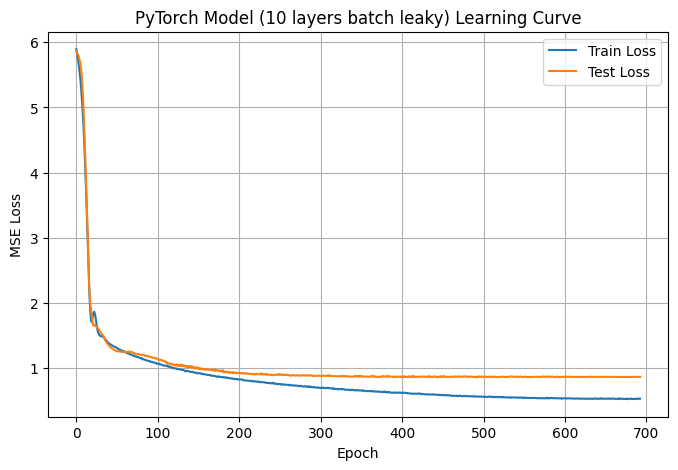

[PyTorch Model (10 layers batch leaky) - Test Set]
MAE:  0.6364
RMSE: 0.9302
R²:   0.6416

[PyTorch Model (10 layers batch leaky) - Training Set]
MAE:  0.4134
RMSE: 0.5625
R²:   0.8692


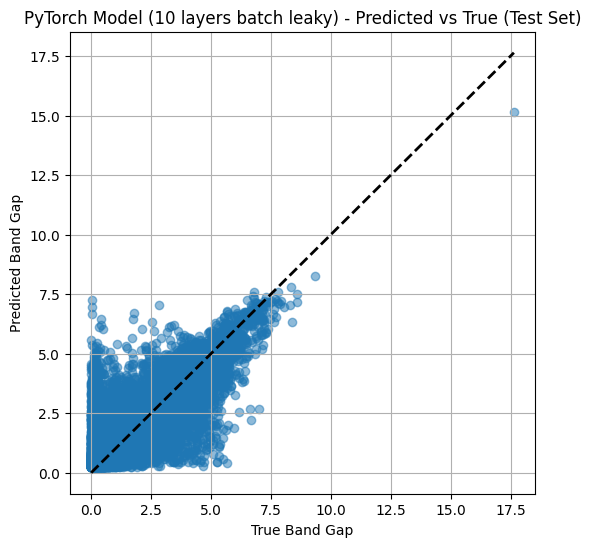

In [144]:
# Make a metrics dictionary
model_layers10_batch_leaky_metrics = evaluate_model(
    model_layers10_batch_leaky,
    X_train_tensor,
    y_train,
    X_test_tensor,
    y_test
)
# Analyze the model
analyze_model(
    model_layers10_batch_leaky_metrics,
    y_test,
    train_losses_layers10_batch_leaky,
    test_losses_layers10_batch_leaky,
    model_name="PyTorch Model (10 layers batch leaky)"
)

## Ensemble Predictions

In [145]:
def ensemble_predict(models, X_tensor):
    """
    Averages predictions from multiple models.

    Args:
        models (list): List of trained PyTorch models
        X_tensor (torch.Tensor): Input features

    Returns:
        np.ndarray: Averaged predictions (numpy array)
    """
    preds = []

    for model in models:
        model.eval()
        with torch.no_grad():
            pred = model(X_tensor).detach().cpu().numpy()
            preds.append(pred)

    # Stack and average predictions
    preds = np.stack(preds, axis=0)  # Shape: (num_models, num_samples, 1)
    avg_preds = np.mean(preds, axis=0)  # Shape: (num_samples, 1)

    return avg_preds


In [146]:
# Assume you have 3 trained models
# models["Random Forest"].fit(X_train_processed, y_train)
models = [model_layers6, model_layers10]

# Ensemble predictions on test data
ensemble_preds = ensemble_predict(models, X_test_tensor)

mae = mean_absolute_error(y_test, ensemble_preds)
rmse = mean_squared_error(y_test, ensemble_preds)
r2 = r2_score(y_test, ensemble_preds)

print(f"[Ensemble Results models 6 and 10 layers]")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

[Ensemble Results models 6 and 10 layers]
MAE:  0.7444
RMSE: 0.9681
R²:   0.5989


# Summary of all

In [192]:
# Print the summaries of all the models based on mae rmse and r2#
# summarize all model by mae and r2 values
print("\nSummary of all models:")
print(f"{'Model':<30} {'MAE':<10} {'RMSE':<10} {'R²':<10}")
for name, result in results.items():
    print(f"{name:<30} {result['mae']:<10.4f} {np.sqrt(result['mae']):<10.4f} {result['r2']:<10.4f}")

print(f"{'PyTorch 3-layers':<30} {model_layers3_metrics['test']['MAE']:<10.4f} {model_layers3_metrics['test']['RMSE']:<10.4f} {model_layers3_metrics['test']['R2']:<10.4f}")
# print(f"{'PyTorch 3-layers train':<30} {model_layers3_metrics['train']['MAE']:<10.4f} {model_layers3_metrics['train']['RMSE']:<10.4f} {model_layers3_metrics['train']['R2']:<10.4f}")
print(f"{'PyTorch 6-layers':<30} {model_layers6_metrics['test']['MAE']:<10.4f} {model_layers6_metrics['test']['RMSE']:<10.4f} {model_layers6_metrics['test']['R2']:<10.4f}")
# print(f"{'PyTorch 6-layers train':<30} {model_layers6_metrics['train']['MAE']:<10.4f} {model_layers6_metrics['train']['RMSE']:<10.4f} {model_layers6_metrics['train']['R2']:<10.4f}")
print(f"{'PyTorch 8-layers':<30} {model_layers8_metrics['test']['MAE']:<10.4f} {model_layers8_metrics['test']['RMSE']:<10.4f} {model_layers8_metrics['test']['R2']:<10.4f}")
print(f"{'PyTorch 10-layers':<30} {model_layers10_metrics['test']['MAE']:<10.4f} {model_layers10_metrics['test']['RMSE']:<10.4f} {model_layers10_metrics['test']['R2']:<10.4f}")
# print(f"{'PyTorch 10-layers train':<30} {model_layers10_metrics['train']['MAE']:<10.4f} {model_layers10_metrics['train']['RMSE']:<10.4f} {model_layers10_metrics['train']['R2']:<10.4f}")
print(f"{'PyTorch 12-layers':<30} {model_layers12_metrics['test']['MAE']:<10.4f} {model_layers12_metrics['test']['RMSE']:<10.4f} {model_layers12_metrics['test']['R2']:<10.4f}")
print(f"{'PyTorch 14-layers':<30} {model_layers14_metrics['test']['MAE']:<10.4f} {model_layers14_metrics['test']['RMSE']:<10.4f} {model_layers14_metrics['test']['R2']:<10.4f}")
print(f"{'Ensemble 6 and 10 layers':<30} {mae:<10.4f} {rmse:<10.4f} {r2:<10.4f}")

print(f"{'6-layers droppout':<30} {model_layers6_dropout_metrics['test']['MAE']:<10.4f} {model_layers6_dropout_metrics['test']['RMSE']:<10.4f} {model_layers6_dropout_metrics['test']['R2']:<10.4f}")
print(f"{'8-layers droppout':<30} {model_layers8_dropout_metrics['test']['MAE']:<10.4f} {model_layers8_dropout_metrics['test']['RMSE']:<10.4f} {model_layers8_dropout_metrics['test']['R2']:<10.4f}")
print(f"{'10-layers droppout':<30} {model_layers10_dropout_metrics['test']['MAE']:<10.4f} {model_layers10_dropout_metrics['test']['RMSE']:<10.4f} {model_layers10_dropout_metrics['test']['R2']:<10.4f}")

print(f"{'6-layers leaky relu, batch':<30} {model_layers6_batch_leaky_metrics['test']['MAE']:<10.4f} {model_layers6_batch_leaky_metrics['test']['RMSE']:<10.4f} {model_layers6_batch_leaky_metrics['test']['R2']:<10.4f}")
print(f"{'8-layers leaky relu, batch':<30} {model_layers8_batch_leaky_metrics['test']['MAE']:<10.4f} {model_layers8_batch_leaky_metrics['test']['RMSE']:<10.4f} {model_layers8_batch_leaky_metrics['test']['R2']:<10.4f}")
print(f"{'10-layers leaky relu, batch':<30} {model_layers10_batch_leaky_metrics['test']['MAE']:<10.4f} {model_layers10_batch_leaky_metrics['test']['RMSE']:<10.4f} {model_layers10_batch_leaky_metrics['test']['R2']:<10.4f}")


Summary of all models:
Model                          MAE        RMSE       R²        
Linear Regression              1.0423     1.0209     0.2864    
Random Forest                  0.6362     0.7976     0.6666    
MLP                            0.7728     0.8791     0.5565    
Random Forest (Ocunda)         0.6499     0.8062     0.6575    
PyTorch 3-layers               0.7547     1.0175     0.5711    
PyTorch 6-layers               0.7007     0.9566     0.6209    
PyTorch 8-layers               0.8054     1.0506     0.5427    
PyTorch 10-layers              0.8213     1.0654     0.5298    
PyTorch 12-layers              0.7680     1.0150     0.5732    
PyTorch 14-layers              0.7371     0.9864     0.5969    
Ensemble 6 and 10 layers       0.7444     0.9681     0.5989    
6-layers droppout              0.7137     0.9640     0.6150    
8-layers droppout              0.7368     0.9862     0.5971    
10-layers droppout             0.7436     0.9945     0.5903    
6-layers leaky r

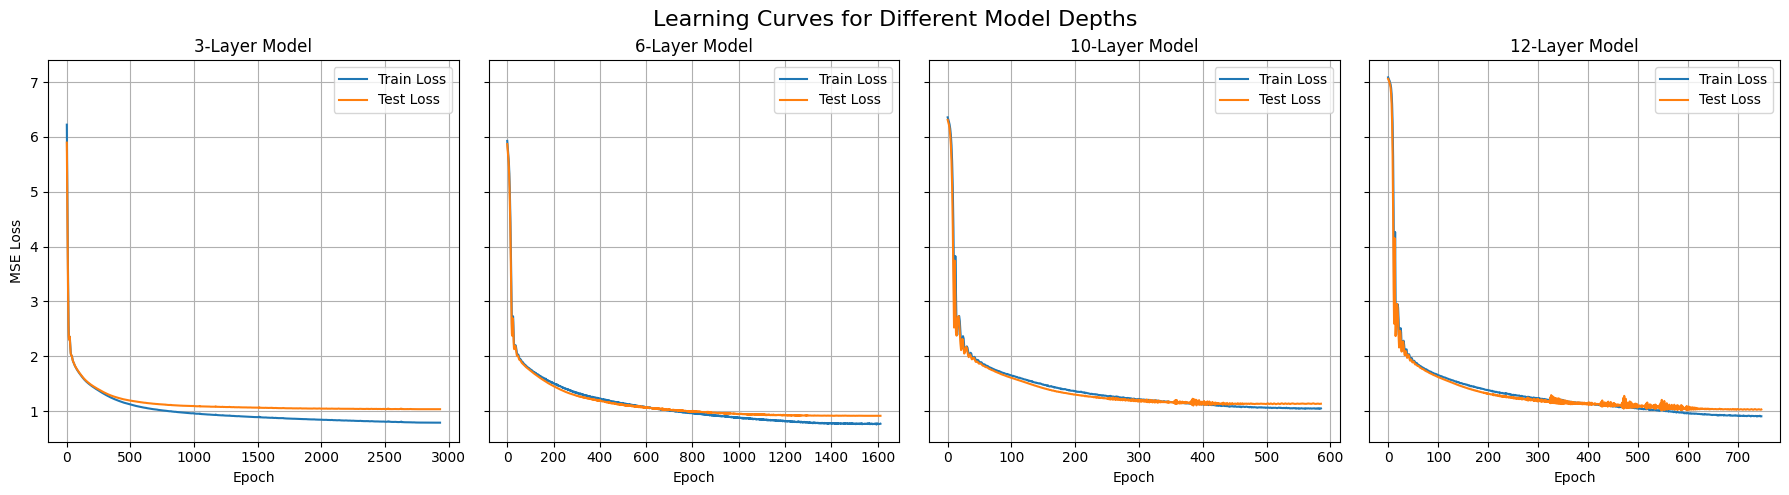

In [148]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

# Model: 3 Layers
axes[0].plot(train_losses_layers3, label="Train Loss")
axes[0].plot(test_losses_layers3, label="Test Loss")
axes[0].set_title("3-Layer Model")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(True)

# Model: 6 Layers
axes[1].plot(train_losses_layers6, label="Train Loss")
axes[1].plot(test_losses_layers6, label="Test Loss")
axes[1].set_title("6-Layer Model")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

# Model: 10 Layers
axes[2].plot(train_losses_layers10, label="Train Loss")
axes[2].plot(test_losses_layers10, label="Test Loss")
axes[2].set_title("10-Layer Model")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True)

# Model: 12 Layers
axes[3].plot(train_losses_layers12, label="Train Loss")
axes[3].plot(test_losses_layers12, label="Test Loss")
axes[3].set_title("12-Layer Model")
axes[3].set_xlabel("Epoch")
axes[3].legend()
axes[3].grid(True)


# Set overall title
fig.suptitle("Learning Curves for Different Model Depths", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()



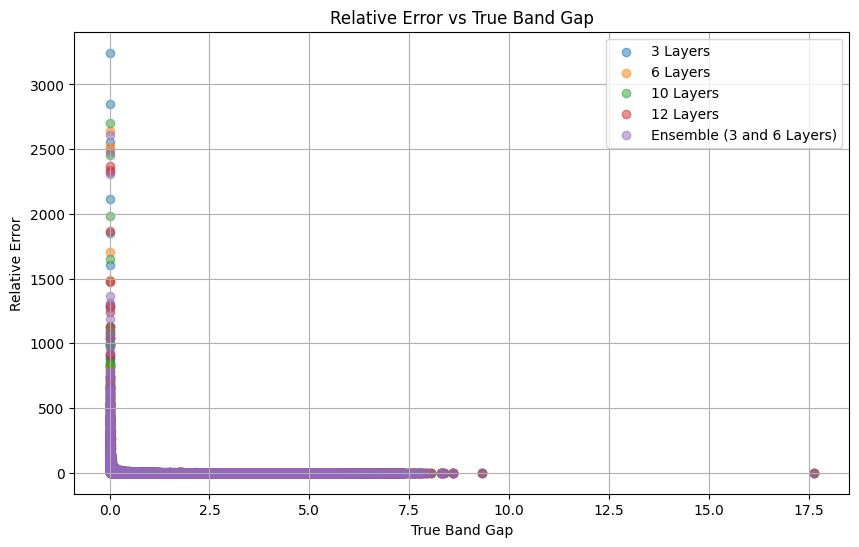

In [149]:
# relative error vs true band gap for 3 6 10 and 12 layers
plt.figure(figsize=(10, 6))
plt.scatter(y_test, np.abs(model_layers3_metrics['test']['y_pred_test'].flatten() - y_test) / y_test, alpha=0.5, label="3 Layers")
plt.scatter(y_test, np.abs(model_layers6_metrics['test']['y_pred_test'].flatten() - y_test) / y_test, alpha=0.5, label="6 Layers")
plt.scatter(y_test, np.abs(model_layers10_metrics['test']['y_pred_test'].flatten() - y_test) / y_test, alpha=0.5, label="10 Layers")
plt.scatter(y_test, np.abs(model_layers12_metrics['test']['y_pred_test'].flatten() - y_test) / y_test, alpha=0.5, label="12 Layers")
plt.scatter(y_test, np.abs(ensemble_preds.flatten() - y_test) / y_test, alpha=0.5, label="Ensemble (3 and 6 Layers)")
plt.xlabel("True Band Gap")
plt.ylabel("Relative Error")
plt.title("Relative Error vs True Band Gap")
plt.legend()
plt.grid(True)
plt.show()

# Analysis

## Random Forest Best Model

### Shap Table

In [ ]:
# Feature importance of tree based model
rf_model = make_pipeline(preprocessor, RandomForestRegressor(random_state=42))
rf_model.fit(X_train, y_train)

importances = rf_model.named_steps["randomforestregressor"].feature_importances_

# Get feature names from the preprocessor
feature_names = rf_model.named_steps["columntransformer"].get_feature_names_out()

In [209]:
# Feature importance using SHAP
rf = rf_model.named_steps["randomforestregressor"]
X_transformed = rf_model.named_steps["columntransformer"].transform(X_test)

if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

feature_names = rf_model.named_steps["columntransformer"].get_feature_names_out()

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_transformed)

shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

AttributeError: Estimator targetencoderwrapper does not provide get_feature_names_out. Did you mean to call pipeline[:-1].get_feature_names_out()?

In [ ]:
# Sort by importance
sorted_idx = np.argsort(importances)[::-1][:20]
top_features = np.array(feature_names)[sorted_idx]
top_importances = importances[sorted_idx]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances, y=top_features)
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
# Using a faster SHAP explainer
rf = rf_model.named_steps["randomforestregressor"]

# Sample fewer rows for faster explanation
X_sample = X_test.sample(250, random_state=42)

# Transform using your pipeline
X_transformed = rf_model.named_steps["columntransformer"].transform(X_sample)

# Only convert if needed
if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

# Get feature names
feature_names = rf_model.named_steps["columntransformer"].get_feature_names_out()

# Use SHAP's auto-detect explainer (faster in new versions)
explainer = shap.Explainer(rf)

# Compute SHAP values
shap_values = explainer(X_transformed)

# Summary plot
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

## 8 Layer Leaky Relu, Batch